In [1]:
from pathlib import Path
import os
import gzip
import shutil
import pandas as pd
import numpy as np
import requests
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem

import torch
from transformers import AutoTokenizer, AutoModel

/home/izirdeli/.conda/envs/esmc/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import sys
sys.path.append("/home/izirdeli/Documents.cglab/DownStreamAnalysis/03.Code")
from plotting_functions import custom_plots
plt.rcParams.update(custom_plots())

In [2]:
DATA_DIR = Path(".")
DATA_DIR.mkdir(exist_ok=True, parents=True)

CHEMBL_DIR = DATA_DIR / "chembl"
ODOR_DIR = DATA_DIR / "odor_datasets"

CHEMBL_DIR.mkdir(exist_ok=True, parents=True)
ODOR_DIR.mkdir(exist_ok=True, parents=True)

### chembl dataset

In [4]:
def download_file(url, dest_path, chunk_size=1024 * 1024):
    dest_path = Path(dest_path)
    if dest_path.exists():
        print(f"[skip] Already exists: {dest_path}")
        return dest_path

    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(dest_path, "wb") as f, tqdm(
            total=total,
            unit="B",
            unit_scale=True,
            desc=dest_path.name
        ) as pbar:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    return dest_path


def gunzip_file(gz_path, out_path=None):
    gz_path = Path(gz_path)
    if out_path is None:
        out_path = gz_path.with_suffix("")  # removes .gz
    out_path = Path(out_path)

    if out_path.exists():
        print(f"[skip] Already uncompressed: {out_path}")
        return out_path

    with gzip.open(gz_path, "rb") as f_in, open(out_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

    print(f"[ok] Uncompressed to: {out_path}")
    return out_path

In [5]:
CHEMBL_CHEMREPS_URL = (
    "https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/latest/"
    "chembl_36_chemreps.txt.gz"
)

chembl_gz = download_file(
    CHEMBL_CHEMREPS_URL,
    CHEMBL_DIR / "chembl_36_chemreps.txt.gz"
)

chembl_txt = gunzip_file(chembl_gz, CHEMBL_DIR / "chembl_36_chemreps.txt")

chembl_36_chemreps.txt.gz: 100%|██████████| 287M/287M [00:22<00:00, 12.6MB/s] 


[ok] Uncompressed to: chembl/chembl_36_chemreps.txt


In [7]:
chembl_df = pd.read_csv(chembl_txt, sep="\t", low_memory=False)

print("Shape:", chembl_df.shape)
print("Columns:", chembl_df.columns.tolist())
chembl_df

Shape: (2854815, 4)
Columns: ['chembl_id', 'canonical_smiles', 'standard_inchi', 'standard_inchi_key']


,chembl_id,canonical_smiles,standard_inchi,standard_inchi_key
0,CHEMBL153534,Cc1cc(-c2csc(N=C(N)N)n2)cn1C,InChI=1S/C10H13N5S/c1-6-3-7(4-15(6)2)8-5-16-10...,MFRNFCWYPYSFQQ-UHFFFAOYSA-N
1,CHEMBL440060,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...,InChI=1S/C123H212N44O34S/c1-19-63(12)96(164-11...,RSEQNZQKBMRQNM-VRGFNVLHSA-N
2,CHEMBL440245,CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...,InChI=1S/C160H268N50O41/c1-23-27-41-95-134(228...,FTKBTEIKPOYCEX-OZSLQWTKSA-N
3,CHEMBL440249,CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...,InChI=1S/C124H154ClN21O39/c1-57(2)48-81-112(17...,UYSXXKGACMHPIM-KFGDMSGDSA-N
4,CHEMBL405398,Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1,InChI=1S/C19H21BrN6O/c20-15-2-1-3-17(18(15)22-...,VDSXZXJEWIWBCG-UHFFFAOYSA-N
...,...,...,...,...
2854810,CHEMBL4298697,C=C1C(=O)O[C@@H]2C3O[C@]3(C)CC/C=C(\C)CC[C@@H]12,InChI=1S/C15H20O3/c1-9-5-4-8-15(3)13(18-15)12-...,KTEXNACQROZXEV-TZNSAIHPSA-N
2854811,CHEMBL4298698,C[n+]1cn([C@@H]2O[C@H](CO[P@@](=O)(S)OP(=O)([O...,InChI=1S/C11H18N5O13P3S/c1-15-3-16(8-5(15)9(19...,OTIKKVINVWNBOQ-LDJOHHLFSA-N
2854812,CHEMBL4298702,c1ccc(C2CC(C3CC(c4ccccc4)OC(c4ccccc4)C3)CC(c3c...,InChI=1S/C34H34O2/c1-5-13-25(14-6-1)31-21-29(2...,NZIGZXNUFVMHNV-UHFFFAOYSA-N
2854813,CHEMBL4298703,CSCC[C@H](NC=O)C(=O)N[C@@H](CCCNC(=N)NS(=O)(=O...,InChI=1S/C78H107N18O21PS2/c1-43-44(2)65(45(3)5...,IIHLOGWTFCCTPB-WTIPWMETSA-N


In [8]:
chembl_df.columns

Index(['chembl_id', 'canonical_smiles', 'standard_inchi',
       'standard_inchi_key'],
      dtype='object')

In [9]:
chembl_smiles = chembl_df[
    ["chembl_id", "canonical_smiles", "standard_inchi_key", "standard_inchi"]
].copy()

# drop rows without SMILES
chembl_smiles = chembl_smiles.dropna(subset=["canonical_smiles"]).copy()

# remove duplicate SMILES for the UMAP background
chembl_smiles = chembl_smiles.drop_duplicates(subset=["canonical_smiles"]).reset_index(drop=True)

chembl_smiles["source"] = "chembl"

print("Unique ChEMBL SMILES:", len(chembl_smiles))
chembl_smiles

Unique ChEMBL SMILES: 2854654


,chembl_id,canonical_smiles,standard_inchi_key,standard_inchi,source
0,CHEMBL153534,Cc1cc(-c2csc(N=C(N)N)n2)cn1C,MFRNFCWYPYSFQQ-UHFFFAOYSA-N,InChI=1S/C10H13N5S/c1-6-3-7(4-15(6)2)8-5-16-10...,chembl
1,CHEMBL440060,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...,RSEQNZQKBMRQNM-VRGFNVLHSA-N,InChI=1S/C123H212N44O34S/c1-19-63(12)96(164-11...,chembl
2,CHEMBL440245,CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...,FTKBTEIKPOYCEX-OZSLQWTKSA-N,InChI=1S/C160H268N50O41/c1-23-27-41-95-134(228...,chembl
3,CHEMBL440249,CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...,UYSXXKGACMHPIM-KFGDMSGDSA-N,InChI=1S/C124H154ClN21O39/c1-57(2)48-81-112(17...,chembl
4,CHEMBL405398,Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1,VDSXZXJEWIWBCG-UHFFFAOYSA-N,InChI=1S/C19H21BrN6O/c20-15-2-1-3-17(18(15)22-...,chembl
...,...,...,...,...,...
2854649,CHEMBL4298697,C=C1C(=O)O[C@@H]2C3O[C@]3(C)CC/C=C(\C)CC[C@@H]12,KTEXNACQROZXEV-TZNSAIHPSA-N,InChI=1S/C15H20O3/c1-9-5-4-8-15(3)13(18-15)12-...,chembl
2854650,CHEMBL4298698,C[n+]1cn([C@@H]2O[C@H](CO[P@@](=O)(S)OP(=O)([O...,OTIKKVINVWNBOQ-LDJOHHLFSA-N,InChI=1S/C11H18N5O13P3S/c1-15-3-16(8-5(15)9(19...,chembl
2854651,CHEMBL4298702,c1ccc(C2CC(C3CC(c4ccccc4)OC(c4ccccc4)C3)CC(c3c...,NZIGZXNUFVMHNV-UHFFFAOYSA-N,InChI=1S/C34H34O2/c1-5-13-25(14-6-1)31-21-29(2...,chembl
2854652,CHEMBL4298703,CSCC[C@H](NC=O)C(=O)N[C@@H](CCCNC(=N)NS(=O)(=O...,IIHLOGWTFCCTPB-WTIPWMETSA-N,InChI=1S/C78H107N18O21PS2/c1-43-44(2)65(45(3)5...,chembl


In [ ]:
chembl_out = CHEMBL_DIR / "chembl_smiles_clean.csv"
chembl_smiles.to_csv(chembl_out, index=False)
print(f"Saved: {chembl_out}")

In [4]:
chembl_smiles = pd.read_csv(CHEMBL_DIR / "chembl_smiles_clean.csv")
print("Reloaded cleaned ChEMBL:", chembl_smiles.shape)
chembl_smiles

Reloaded cleaned ChEMBL: (2854654, 5)


,chembl_id,canonical_smiles,standard_inchi_key,standard_inchi,source
0,CHEMBL153534,Cc1cc(-c2csc(N=C(N)N)n2)cn1C,MFRNFCWYPYSFQQ-UHFFFAOYSA-N,InChI=1S/C10H13N5S/c1-6-3-7(4-15(6)2)8-5-16-10...,chembl
1,CHEMBL440060,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...,RSEQNZQKBMRQNM-VRGFNVLHSA-N,InChI=1S/C123H212N44O34S/c1-19-63(12)96(164-11...,chembl
2,CHEMBL440245,CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...,FTKBTEIKPOYCEX-OZSLQWTKSA-N,InChI=1S/C160H268N50O41/c1-23-27-41-95-134(228...,chembl
3,CHEMBL440249,CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...,UYSXXKGACMHPIM-KFGDMSGDSA-N,InChI=1S/C124H154ClN21O39/c1-57(2)48-81-112(17...,chembl
4,CHEMBL405398,Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1,VDSXZXJEWIWBCG-UHFFFAOYSA-N,InChI=1S/C19H21BrN6O/c20-15-2-1-3-17(18(15)22-...,chembl
...,...,...,...,...,...
2854649,CHEMBL4298697,C=C1C(=O)O[C@@H]2C3O[C@]3(C)CC/C=C(\C)CC[C@@H]12,KTEXNACQROZXEV-TZNSAIHPSA-N,InChI=1S/C15H20O3/c1-9-5-4-8-15(3)13(18-15)12-...,chembl
2854650,CHEMBL4298698,C[n+]1cn([C@@H]2O[C@H](CO[P@@](=O)(S)OP(=O)([O...,OTIKKVINVWNBOQ-LDJOHHLFSA-N,InChI=1S/C11H18N5O13P3S/c1-15-3-16(8-5(15)9(19...,chembl
2854651,CHEMBL4298702,c1ccc(C2CC(C3CC(c4ccccc4)OC(c4ccccc4)C3)CC(c3c...,NZIGZXNUFVMHNV-UHFFFAOYSA-N,InChI=1S/C34H34O2/c1-5-13-25(14-6-1)31-21-29(2...,chembl
2854652,CHEMBL4298703,CSCC[C@H](NC=O)C(=O)N[C@@H](CCCNC(=N)NS(=O)(=O...,IIHLOGWTFCCTPB-WTIPWMETSA-N,InChI=1S/C78H107N18O21PS2/c1-43-44(2)65(45(3)5...,chembl


### molformer embeddings

In [11]:
molformer_tokenizer = AutoTokenizer.from_pretrained("ibm-research/MoLFormer-XL-both-10pct", trust_remote_code=True)
molformer_model = AutoModel.from_pretrained("ibm-research/MoLFormer-XL-both-10pct", trust_remote_code=True).eval().cuda()

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
molformer_model = molformer_model.to(device)
molformer_model.eval()

EMB_DIR = Path("embeddings")
EMB_DIR.mkdir(exist_ok=True, parents=True)

unique_smiles = chembl_smiles["canonical_smiles"].dropna().drop_duplicates().tolist()
print("Unique SMILES:", len(unique_smiles))

Unique SMILES: 2854654


In [15]:
lengths = []
for smi in tqdm(unique_smiles):
    ids = molformer_tokenizer(smi, add_special_tokens=True)["input_ids"]
    lengths.append(len(ids))

lengths = np.array(lengths)
print(
    "n_smiles:", len(lengths),
    "\nmin/median/mean/95%/99%/max:",
    lengths.min(),
    int(np.median(lengths)),
    lengths.mean(),
    int(np.percentile(lengths, 95)),
    int(np.percentile(lengths, 99)),
    lengths.max()
)

100%|██████████| 2854654/2854654 [02:29<00:00, 19060.34it/s]


n_smiles: 2854654 
min/median/mean/95%/99%/max: 3 50 54.702587774210116 88 174 1505


In [16]:
def get_molformer_embeddings_batch(smiles_batch, max_length=256):
    inputs = molformer_tokenizer(
        smiles_batch,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_length
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = molformer_model(**inputs)

    if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
        emb = outputs.pooler_output   # (batch_size, hidden_dim)
    else:
        emb = outputs.last_hidden_state[:, 0, :]   # CLS token

    return emb.detach().cpu().numpy().astype(np.float32)

In [17]:
batch_size = 64   
max_length = 256

all_embeddings = []
all_smiles = []

for i in tqdm(range(0, len(unique_smiles), batch_size)):
    batch_smiles = unique_smiles[i:i + batch_size]

    try:
        batch_emb = get_molformer_embeddings_batch(batch_smiles, max_length=max_length)
        all_embeddings.append(batch_emb)
        all_smiles.extend(batch_smiles)

    except Exception as e:
        print(f"Failed batch {i}:{i+batch_size} -> {e}")

100%|██████████| 44604/44604 [10:22:12<00:00,  1.19it/s]  


In [18]:
embedding_matrix = np.vstack(all_embeddings)

embeddings_df = pd.DataFrame({
    "canonical_smiles": all_smiles
})

embeddings_df.to_csv(EMB_DIR / "molformer_chembl_smiles.csv", index=False)
np.save(EMB_DIR / "molformer_chembl_embeddings.npy", embedding_matrix)

print("Saved:")
print(" -", EMB_DIR / "molformer_chembl_smiles.csv")
print(" -", EMB_DIR / "molformer_chembl_embeddings.npy")
print("Embedding matrix shape:", embedding_matrix.shape)

Saved:
 - embeddings/molformer_chembl_smiles.csv
 - embeddings/molformer_chembl_embeddings.npy
Embedding matrix shape: (2854654, 768)


### umap

In [3]:
EMB_DIR = Path("embeddings")

chembl_smiles_emb = pd.read_csv(EMB_DIR / "molformer_chembl_smiles.csv")
chembl_embeddings = np.load(EMB_DIR / "molformer_chembl_embeddings.npy")

print(chembl_smiles_emb.shape)
print(chembl_embeddings.shape, chembl_embeddings.dtype)
chembl_smiles_emb.head()

(2854654, 1)
(2854654, 768) float32


,canonical_smiles
0,Cc1cc(-c2csc(N=C(N)N)n2)cn1C
1,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...
2,CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...
3,CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...
4,Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1


In [21]:
import umap

sample_size = 100_000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(chembl_embeddings), size=sample_size, replace=False)

X_sample = chembl_embeddings[sample_idx]
meta_sample = chembl_smiles_emb.iloc[sample_idx].copy().reset_index(drop=True)

umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    low_memory=True,
    random_state=42,
    verbose=True
)

sample_umap = umap_model.fit_transform(X_sample)

meta_sample["UMAP1"] = sample_umap[:, 0]
meta_sample["UMAP2"] = sample_umap[:, 1]

meta_sample.to_csv(EMB_DIR / "chembl_molformer_umap_sample100k.csv", index=False)
np.save(EMB_DIR / "chembl_molformer_umap_sample100k_idx.npy", sample_idx)

print("Saved sampled UMAP.")
print(meta_sample.shape)

/home/izirdeli/.conda/envs/esmc/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Fri Mar 20 15:07:36 2026 Construct fuzzy simplicial set
Fri Mar 20 15:07:37 2026 Finding Nearest Neighbors
Fri Mar 20 15:07:37 2026 Building RP forest with 21 trees
Fri Mar 20 15:07:45 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	 4  /  17
	 5  /  17
	Stopping threshold met -- exiting after 5 iterations
Fri Mar 20 15:08:15 2026 Finished Nearest Neighbor Search
Fri Mar 20 15:08:18 2026 Construct embedding


Epochs completed:   2%| ▏          3/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  11%| █          22/200 [00:03]

...

	completed  160  /  200 epochs


Epochs completed:  91%| █████████  182/200 [00:30]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:33]


Fri Mar 20 15:09:02 2026 Finished embedding
Saved sampled UMAP.
(100000, 3)


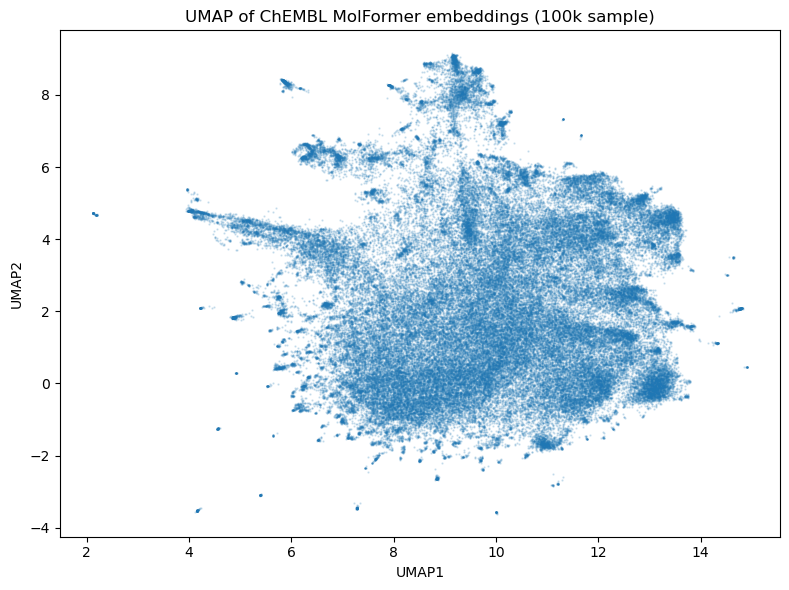

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(
    meta_sample["UMAP1"],
    meta_sample["UMAP2"],
    s=0.4,
    alpha=0.2,
    rasterized=True
)
plt.title("UMAP of ChEMBL MolFormer embeddings (100k sample)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.tight_layout()
plt.show()

In [26]:
batch_size = 50_000

all_coords = np.empty((len(chembl_embeddings), 2), dtype=np.float32)

# fill sampled rows from the learned embedding
all_coords[sample_idx] = sample_umap.astype(np.float32)

mask = np.ones(len(chembl_embeddings), dtype=bool)
mask[sample_idx] = False
remaining_idx = np.where(mask)[0]

for start in range(0, len(remaining_idx), batch_size):
    end = min(start + batch_size, len(remaining_idx))
    idx_batch = remaining_idx[start:end]
    X_batch = chembl_embeddings[idx_batch]

    coords_batch = umap_model.transform(X_batch)
    all_coords[idx_batch] = coords_batch.astype(np.float32)

    print(f"Transformed {end}/{len(remaining_idx)} remaining molecules")

Fri Mar 20 15:12:44 2026 Worst tree score: 0.44662000
Fri Mar 20 15:12:44 2026 Mean tree score: 0.45412762
Fri Mar 20 15:12:44 2026 Best tree score: 0.46320000
Fri Mar 20 15:12:46 2026 Forward diversification reduced edges from 3000000 to 917103
Fri Mar 20 15:12:48 2026 Reverse diversification reduced edges from 917103 to 917103
Fri Mar 20 15:12:49 2026 Degree pruning reduced edges from 1162094 to 1161698
Fri Mar 20 15:12:49 2026 Resorting data and graph based on tree order
Fri Mar 20 15:12:50 2026 Building and compiling search function


Epochs completed:  23%| ██▎        7/30 [00:00]

	completed  0  /  30 epochs
	completed  3  /  30 epochs
	completed  6  /  30 epochs
	completed  9  /  30 epochs


Epochs completed:  43%| ████▎      13/30 [00:00]

	completed  12  /  30 epochs
	completed  15  /  30 epochs


...

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs


Epochs completed:  75%| ███████▌   75/100 [00:00]

	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs


Epochs completed: 100%| ██████████ 100/100 [00:00]

	completed  90  /  100 epochs
Transformed 2754654/2754654 remaining molecules


In [27]:
chembl_umap_full = chembl_smiles_emb.copy()
chembl_umap_full["UMAP1"] = all_coords[:, 0]
chembl_umap_full["UMAP2"] = all_coords[:, 1]

chembl_umap_full.to_csv(EMB_DIR / "chembl_molformer_umap_full.csv", index=False)
np.save(EMB_DIR / "chembl_molformer_umap_full.npy", all_coords)

print("Saved full projected UMAP.")
print(chembl_umap_full.shape)

Saved full projected UMAP.
(2854654, 3)


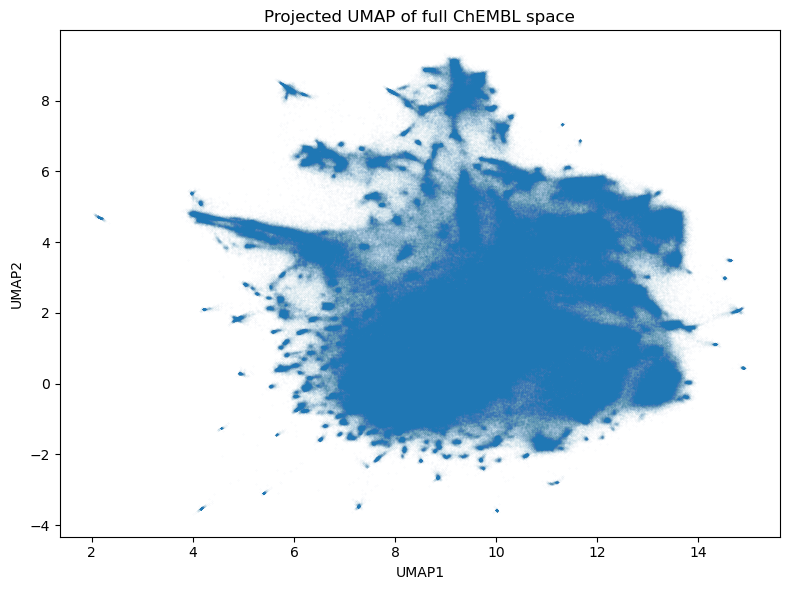

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(
    chembl_umap_full["UMAP1"],
    chembl_umap_full["UMAP2"],
    s=0.05,
    alpha=0.05,
    rasterized=True
)
plt.title("Projected UMAP of full ChEMBL space")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.tight_layout()
plt.show()

# M2OR SMILES

/home/izirdeli/.conda/envs/esmc/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


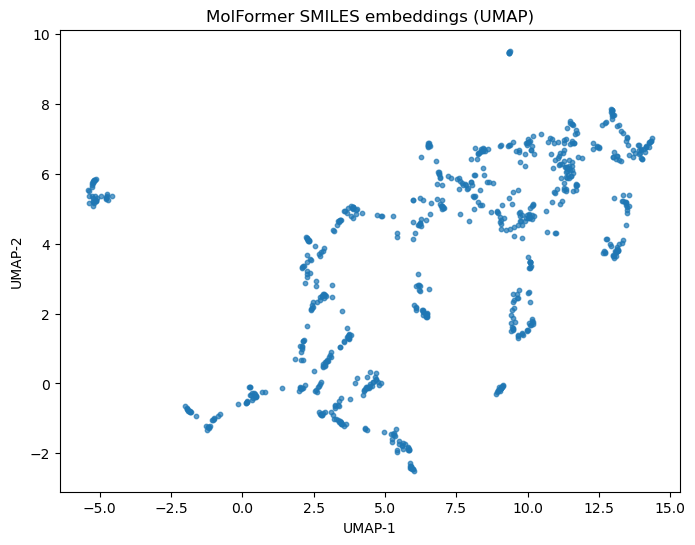

In [32]:
smiles_embeddings = torch.load("../Model/Embeddings/molecules/molformer_smiles_embeddings.pt")

smiles = list(smiles_embeddings.keys())
emb_matrix = torch.stack([smiles_embeddings[smi] for smi in smiles]).numpy()

reducer = umap.UMAP(n_neighbors=10, 
                    min_dist=0.1, 
                    metric='cosine', 
                    random_state=42)

embedding_2d = reducer.fit_transform(emb_matrix)

plt.figure(figsize=(8, 6))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=10, alpha=0.7)
plt.title("MolFormer SMILES embeddings (UMAP)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

# Pyrfume: Leffingwell & Goodscents

In [33]:
import pyrfume

ODOR_DIR = Path("odor_datasets")
ODOR_DIR.mkdir(exist_ok=True, parents=True)

leffingwell_df = pyrfume.load_data("leffingwell/molecules.csv")
goodscents_df  = pyrfume.load_data("goodscents/molecules.csv")

print("Leffingwell shape:", leffingwell_df.shape)
print("GoodScents shape :", goodscents_df.shape)

Leffingwell shape: (3522, 4)
GoodScents shape : (4565, 4)


In [35]:
print(leffingwell_df.columns)
print(goodscents_df.columns)

Index(['MolecularWeight', 'IsomericSMILES', 'IUPACName', 'name'], dtype='object')
Index(['MolecularWeight', 'IsomericSMILES', 'IUPACName', 'name'], dtype='object')


In [36]:
leffingwell_df

,MolecularWeight,IsomericSMILES,IUPACName,name
CID,,,,
-955348933095,240.387,CCCCC=COC(=O)CCCCCCCC,NaN,Hexenyl nonanoate
-923209957509,196.290,CC(=O)OCC1C=CC(C(C)C)CC1,NaN,Tetrahydrocuminyl acetate
-874408321546,244.331,CCCCCCCCC(OC(C)=O)C(=O)OC,NaN,Methyl acetoxydecanoate
-873963935677,198.306,CCCCC=COC(=O)C(C)CCC,NaN,Hexenyl methylvalerate
-862841422647,148.271,CCCC(S)COCC,NaN,Ethoxymethylbutanethiol
...,...,...,...,...
154241350,222.400,CCC1CSSSC1(CC)CC,"4,4,5-triethyltrithiane","4,4,5-triethyltrithiane"
155323379,126.300,CC(S)SS,1-(disulfanyl)ethanethiol,schembl22694105
158699780,174.310,CCC(C)C(=S)OCC(C)C,O-(2-methylpropyl) 2-methylbutanethioate,O-(2-methylpropyl) 2-methylbutanethioate


In [40]:
leffingwell_clean = leffingwell_df.rename(
    columns={"IsomericSMILES": "canonical_smiles"}
).copy()
leffingwell_clean["source"] = "leffingwell"

goodscents_clean = goodscents_df.rename(
    columns={"IsomericSMILES": "canonical_smiles"}
).copy()
goodscents_clean["source"] = "goodscents"

In [42]:
lg_merged = pd.concat(
    [leffingwell_clean, goodscents_clean],
    ignore_index=True,
    sort=False
)

print("Merged LG shape before dedup:", lg_merged.shape)

Merged LG shape before dedup: (8087, 5)


In [43]:
lg_smiles = lg_merged.drop_duplicates(subset=["canonical_smiles"]).reset_index(drop=True)
lg_smiles["merged_source"] = "leffingwell_goodscents"

print("Merged LG shape after dedup:", lg_smiles.shape)
lg_smiles

Merged LG shape after dedup: (5862, 6)


,MolecularWeight,canonical_smiles,IUPACName,name,source,merged_source
0,240.387,CCCCC=COC(=O)CCCCCCCC,NaN,Hexenyl nonanoate,leffingwell,leffingwell_goodscents
1,196.290,CC(=O)OCC1C=CC(C(C)C)CC1,NaN,Tetrahydrocuminyl acetate,leffingwell,leffingwell_goodscents
2,244.331,CCCCCCCCC(OC(C)=O)C(=O)OC,NaN,Methyl acetoxydecanoate,leffingwell,leffingwell_goodscents
3,198.306,CCCCC=COC(=O)C(C)CCC,NaN,Hexenyl methylvalerate,leffingwell,leffingwell_goodscents
4,148.271,CCCC(S)COCC,NaN,Ethoxymethylbutanethiol,leffingwell,leffingwell_goodscents
...,...,...,...,...,...,...
5857,386.270,C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H...,"calcium;[(2R,3S,4R,5R)-3,4-dihydroxy-5-(6-oxo-...",calcium 5'-inosinate,goodscents,leffingwell_goodscents
5858,401.280,C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)COP(=O...,"calcium;[(2R,3S,4R,5R)-5-(2-amino-6-oxo-1H-pur...",calcium 5'-guanylate,goodscents,leffingwell_goodscents
5859,439.400,C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)COP(=O...,"dipotassium;[(2R,3S,4R,5R)-5-(2-amino-6-oxo-1H...",dipotassium 5'-guanylate,goodscents,leffingwell_goodscents
5860,175.300,CCC1SC(N=C(S1)C)C,"2-ethyl-4,6-dimethyl-4H-1,3,5-dithiazine","2-ethyl-4,6-dimethyl-4H-1,3,5-dithiazine",goodscents,leffingwell_goodscents


In [46]:
lg_out = ODOR_DIR / "leffingwell_goodscents_smiles.csv"
lg_smiles.to_csv(lg_out, index=False)
print(f"Saved: {lg_out}")

Saved: odor_datasets/leffingwell_goodscents_smiles.csv


In [48]:
#reload
lg_smiles = pd.read_csv(ODOR_DIR / "leffingwell_goodscents_smiles.csv")
print(lg_smiles.shape)
lg_smiles

(5862, 6)


,MolecularWeight,canonical_smiles,IUPACName,name,source,merged_source
0,240.387,CCCCC=COC(=O)CCCCCCCC,NaN,Hexenyl nonanoate,leffingwell,leffingwell_goodscents
1,196.290,CC(=O)OCC1C=CC(C(C)C)CC1,NaN,Tetrahydrocuminyl acetate,leffingwell,leffingwell_goodscents
2,244.331,CCCCCCCCC(OC(C)=O)C(=O)OC,NaN,Methyl acetoxydecanoate,leffingwell,leffingwell_goodscents
3,198.306,CCCCC=COC(=O)C(C)CCC,NaN,Hexenyl methylvalerate,leffingwell,leffingwell_goodscents
4,148.271,CCCC(S)COCC,NaN,Ethoxymethylbutanethiol,leffingwell,leffingwell_goodscents
...,...,...,...,...,...,...
5857,386.270,C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H...,"calcium;[(2R,3S,4R,5R)-3,4-dihydroxy-5-(6-oxo-...",calcium 5'-inosinate,goodscents,leffingwell_goodscents
5858,401.280,C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)COP(=O...,"calcium;[(2R,3S,4R,5R)-5-(2-amino-6-oxo-1H-pur...",calcium 5'-guanylate,goodscents,leffingwell_goodscents
5859,439.400,C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)COP(=O...,"dipotassium;[(2R,3S,4R,5R)-5-(2-amino-6-oxo-1H...",dipotassium 5'-guanylate,goodscents,leffingwell_goodscents
5860,175.300,CCC1SC(N=C(S1)C)C,"2-ethyl-4,6-dimethyl-4H-1,3,5-dithiazine","2-ethyl-4,6-dimethyl-4H-1,3,5-dithiazine",goodscents,leffingwell_goodscents


In [49]:
unique_smiles_lg = lg_smiles["canonical_smiles"].dropna().drop_duplicates().tolist()
print("Unique LG SMILES:", len(unique_smiles_lg))

Unique LG SMILES: 5862


In [50]:
lengths = []
for smi in tqdm(unique_smiles_lg):
    ids = molformer_tokenizer(smi, add_special_tokens=True)["input_ids"]
    lengths.append(len(ids))

lengths = np.array(lengths)
print("n_smiles:", len(lengths))
print(
    "min/median/mean/95%/99%/max:",
    lengths.min(),
    int(np.median(lengths)),
    lengths.mean(),
    int(np.percentile(lengths, 95)),
    int(np.percentile(lengths, 99)),
    lengths.max()
)

100%|██████████| 5862/5862 [00:00<00:00, 34797.55it/s]

n_smiles: 5862
min/median/mean/95%/99%/max: 3 22 22.75196178778574 37 55 205


In [51]:
device = "cuda" if torch.cuda.is_available() else "cpu"
molformer_model = molformer_model.to(device)
molformer_model.eval()

def get_molformer_embeddings_batch(smiles_batch, max_length=256):
    inputs = molformer_tokenizer(
        smiles_batch,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_length
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = molformer_model(**inputs)

    if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
        emb = outputs.pooler_output
    else:
        emb = outputs.last_hidden_state[:, 0, :]

    return emb.detach().cpu().numpy().astype(np.float32)

In [52]:
batch_size = 64
max_length = 256

all_embeddings_lg = []
all_smiles_lg = []

for i in tqdm(range(0, len(unique_smiles_lg), batch_size)):
    batch_smiles = unique_smiles_lg[i:i + batch_size]

    try:
        batch_emb = get_molformer_embeddings_batch(batch_smiles, max_length=max_length)
        all_embeddings_lg.append(batch_emb)
        all_smiles_lg.extend(batch_smiles)
    except Exception as e:
        print(f"Failed batch {i}:{i+batch_size} -> {e}")

100%|██████████| 92/92 [00:29<00:00,  3.09it/s]


In [53]:
embedding_matrix_lg = np.vstack(all_embeddings_lg)

lg_embeddings_df = pd.DataFrame({
    "canonical_smiles": all_smiles_lg
})

lg_embeddings_df.to_csv(ODOR_DIR / "molformer_leffingwell_goodscents_smiles.csv", index=False)
np.save(ODOR_DIR / "molformer_leffingwell_goodscents_embeddings.npy", embedding_matrix_lg)

print("Saved:")
print(" -", ODOR_DIR / "molformer_leffingwell_goodscents_smiles.csv")
print(" -", ODOR_DIR / "molformer_leffingwell_goodscents_embeddings.npy")
print("Embedding matrix shape:", embedding_matrix_lg.shape)

Saved:
 - odor_datasets/molformer_leffingwell_goodscents_smiles.csv
 - odor_datasets/molformer_leffingwell_goodscents_embeddings.npy
Embedding matrix shape: (5862, 768)


In [54]:
lg_smiles_emb = pd.read_csv(ODOR_DIR / "molformer_leffingwell_goodscents_smiles.csv")
lg_embeddings = np.load(ODOR_DIR / "molformer_leffingwell_goodscents_embeddings.npy")

print(lg_smiles_emb.shape)
print(lg_embeddings.shape)

(5862, 1)
(5862, 768)


In [56]:
lg_umap = umap_model.transform(lg_embeddings)

lg_plot = lg_smiles_emb.copy()
lg_plot["UMAP1"] = lg_umap[:, 0]
lg_plot["UMAP2"] = lg_umap[:, 1]

lg_plot.to_csv(ODOR_DIR / "leffingwell_goodscents_projected_on_chembl_umap.csv", index=False)

print("Projected LG shape:", lg_plot.shape)
lg_plot

Epochs completed:  38%| ███▊       38/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs


Epochs completed:  70%| ███████    70/100 [00:00]

	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs


Epochs completed: 100%| ██████████ 100/100 [00:00]

	completed  80  /  100 epochs
	completed  90  /  100 epochs
Projected LG shape: (5862, 3)


,canonical_smiles,UMAP1,UMAP2
0,CCCCC=COC(=O)CCCCCCCC,8.620339,5.564192
1,CC(=O)OCC1C=CC(C(C)C)CC1,9.295341,5.839337
2,CCCCCCCCC(OC(C)=O)C(=O)OC,8.727349,5.508401
3,CCCCC=COC(=O)C(C)CCC,8.767900,5.513134
4,CCCC(S)COCC,8.674513,5.324518
...,...,...,...
5857,C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H...,7.964683,5.391421
5858,C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)COP(=O...,8.203753,5.169365
5859,C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)COP(=O...,7.844352,5.426914
5860,CCC1SC(N=C(S1)C)C,10.727818,4.086465


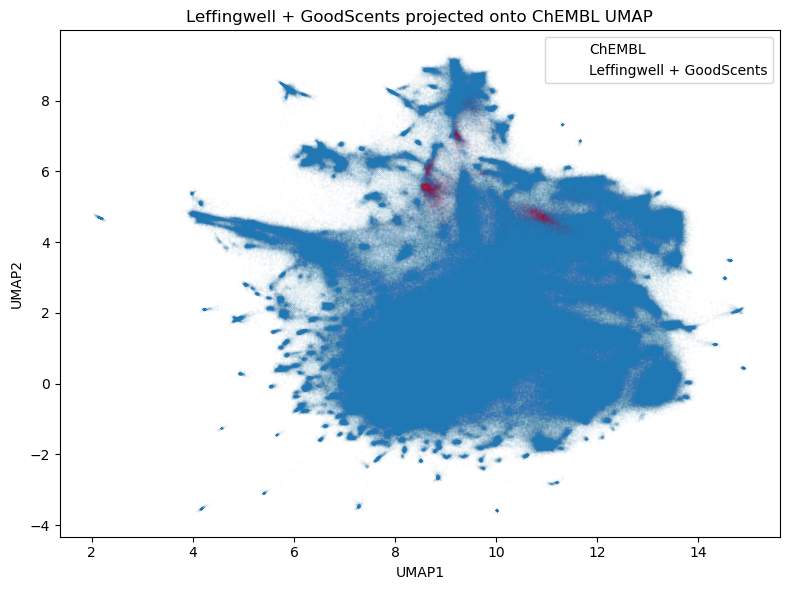

In [79]:
plt.figure(figsize=(8, 6))

# full ChEMBL background
plt.scatter(
    chembl_umap_full["UMAP1"],
    chembl_umap_full["UMAP2"],
    s=0.05,
    alpha=0.05,
    rasterized=True,
    color="#1f77b4",
    label="ChEMBL"
)

# Leffingwell + GoodScents overlay
plt.scatter(
    lg_plot["UMAP1"],
    lg_plot["UMAP2"],
    s=0.08,
    alpha=0.08,
    color="crimson",
    label="Leffingwell + GoodScents"
)

plt.title("Leffingwell + GoodScents projected onto ChEMBL UMAP")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend()
plt.tight_layout()
plt.show()

# M2OR smiles

In [80]:
m2or_path = "../Model/Embeddings/molecules/molformer_smiles_embeddings.pt"

m2or_embeddings_dict = torch.load(m2or_path)

print(type(m2or_embeddings_dict))
print("Number of M2OR SMILES:", len(m2or_embeddings_dict))

<class 'dict'>
Number of M2OR SMILES: 754


In [81]:
m2or_smiles = list(m2or_embeddings_dict.keys())

m2or_matrix = torch.stack([
    m2or_embeddings_dict[smi] for smi in m2or_smiles
]).cpu().numpy().astype(np.float32)

m2or_plot = pd.DataFrame({
    "canonical_smiles": m2or_smiles,
    "source": "m2or"
})

print(m2or_plot.shape)
print(m2or_matrix.shape)

(754, 2)
(754, 768)


In [82]:
print("ChEMBL embedding dim:", chembl_embeddings.shape[1])
print("LG embedding dim    :", lg_embeddings.shape[1])
print("M2OR embedding dim  :", m2or_matrix.shape[1])

ChEMBL embedding dim: 768
LG embedding dim    : 768
M2OR embedding dim  : 768


In [83]:
m2or_umap = umap_model.transform(m2or_matrix)

m2or_plot["UMAP1"] = m2or_umap[:, 0]
m2or_plot["UMAP2"] = m2or_umap[:, 1]

print(m2or_plot.shape)
m2or_plot.head()

Epochs completed: 100%| ██████████ 100/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
(754, 4)


,canonical_smiles,source,UMAP1,UMAP2
0,CC1=CC[C@H](CC1)C(=C)C,m2or,9.640946,5.898460
1,CC1=CC[C@@H](CC1=O)C(=C)C,m2or,9.391557,7.711256
2,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,m2or,10.065674,4.400023
3,CCCCO,m2or,8.588260,5.486904
4,CCCCOCC(C)O,m2or,8.641781,5.637343


In [84]:
m2or_plot.to_csv("embeddings/m2or_projected_on_chembl_umap.csv", index=False)
print("Saved M2OR projected coordinates")

Saved M2OR projected coordinates


/tmp/ipykernel_2980718/557161490.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


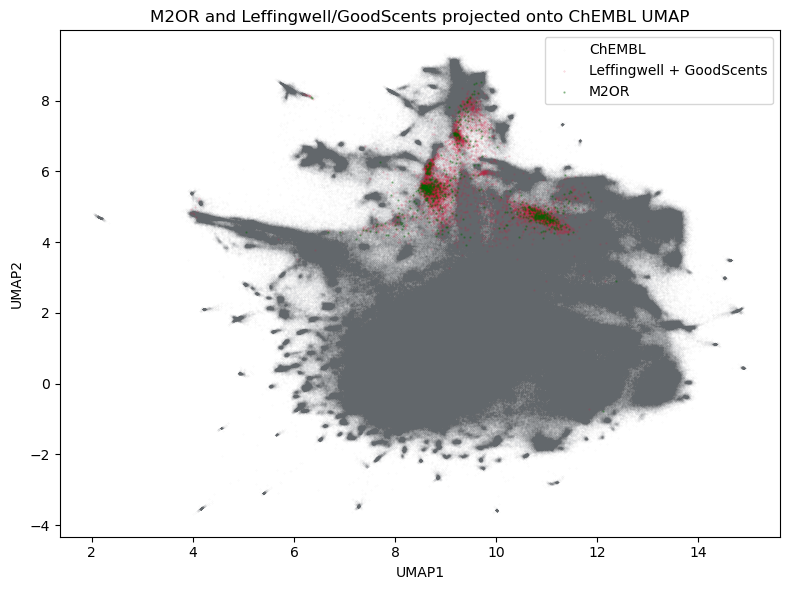

In [95]:
plt.figure(figsize=(8, 6))

# ChEMBL background
plt.scatter(
    chembl_umap_full["UMAP1"],
    chembl_umap_full["UMAP2"],
    s=0.05,
    alpha=0.05,
    rasterized=True,
    color="#62676b",
    label="ChEMBL"
)

# Leffingwell + GoodScents
plt.scatter(
    lg_plot["UMAP1"],
    lg_plot["UMAP2"],
    s=0.1,
    alpha=0.3,
    color="crimson",
    label="Leffingwell + GoodScents"
)

# M2OR
plt.scatter(
    m2or_plot["UMAP1"],
    m2or_plot["UMAP2"],
    s=0.4,
    alpha=0.4,
    color="darkgreen",
    label="M2OR"
)

plt.title("M2OR and Leffingwell/GoodScents projected onto ChEMBL UMAP")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend()
plt.tight_layout()
plt.show()